[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_1/01C-DataHandlingAndVisualization.ipynb)

# 01C — Data Handling and Visualization
(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**  
**Class 1, Notebook C — Hour 3**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm ()

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

This notebook introduces the basic data workflow used throughout the course.

The goal is not to become a pandas expert. The goal is to develop the habit of looking carefully at data before fitting models.

## Learning objectives

By the end of this notebook, students should be able to:

- describe the structure of a tabular dataset, and the vocabulary of samples, features and targets;
- load a dataset into pandas, and check that it loaded correctly;
- inspect rows, columns, data types and missing values;
- select columns, filter rows, derive new columns and sort a table;
- compute summaries, both overall and group by group;
- create histograms, scatter plots and box plots, and read them critically;
- interpret a correlation, and recognise what it cannot tell you;
- use exploratory analysis to judge whether a modelling problem is likely to be solvable.

# 1. Why explore data before modeling?

Machine learning does not start with a model. It starts with data.

Suppose we want to predict one scientific measurement from another. Before fitting a model, we should ask:

- Are the measurements reasonable?
- Are there missing values?
- Are there obvious outliers?
- Are the units correct?
- Do the variables appear related?
- Is there anything suspicious in the data?

A machine learning model will usually produce an answer even when the data contain errors. Exploratory analysis helps us detect problems before they contaminate the modelling stage.

The following toy example illustrates the idea.

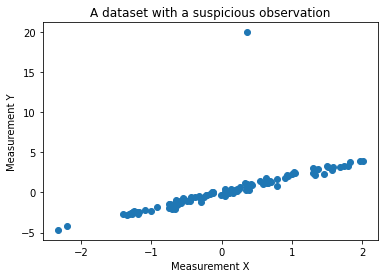

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

x = rng.normal(size=100)
y = 2 * x + rng.normal(scale=0.3, size=100)

y[5] = 20        # one suspicious observation

plt.scatter(x, y)

plt.xlabel("Measurement X")
plt.ylabel("Measurement Y")
plt.title("A dataset with a suspicious observation")

plt.show()

At first sight, the points appear to follow a clear trend:

- larger values of `X` tend to correspond to larger values of `Y`;
- the relationship looks approximately linear;
- however, one observation is far away from all the others.

Before fitting a model, a scientist would usually investigate this point.

Possible explanations include:

- a measurement error;
- a faulty sensor;
- an incorrect unit conversion;
- a data-entry mistake;
- a genuinely unusual observation.

Notice that none of these questions require machine learning. They require understanding the data.

This process is often called **exploratory data analysis (EDA)**.

The goal of EDA is not to build a model. The goal is to understand the dataset well enough that building a model becomes meaningful.

# 2. Dataset anatomy

A tabular dataset is organized as rows and columns.

This structure is simple, but it is the starting point for most machine learning workflows.

The goal of this section is to introduce vocabulary that will appear repeatedly throughout the course:

- observations;
- variables;
- features;
- targets;
- numerical variables;
- categorical variables;
- dataset shape;
- feature space.

## 2.1 What is pandas?

In the previous notebook, we worked mostly with NumPy arrays.

NumPy is excellent for numerical arrays, but real datasets often come with additional structure:

- column names;
- different data types in different columns;
- missing values;
- categorical labels;
- row indices;
- data loaded from CSV or Excel files.

**pandas** is a Python library designed for working with this kind of tabular data.

The central pandas object is the `DataFrame`.

A `DataFrame` is similar to a spreadsheet or a database table:

- it has rows and columns;
- columns have names;
- different columns can contain different kinds of data;
- we can select, filter, group, summarize and plot the data.

pandas is popular because it makes many common data-analysis tasks concise and readable. It is also widely used in scientific computing, data science and machine learning workflows.

However, pandas is not the only option.

Common alternatives include:

- **NumPy**, when the data are purely numerical arrays and performance/simple array operations matter;
- **Polars**, a newer DataFrame library often faster for large tabular datasets;
- **SQL**, when data are stored in relational databases;
- **PySpark** or similar distributed tools, when datasets are too large for a single machine;
- domain-specific tools, when data come from specialized scientific formats.

In this course, we use pandas because it is standard, readable, and sufficient for the small to medium-sized datasets used in teaching.

### What kinds of operations does pandas allow?

At this stage, you do not need to memorize pandas syntax.

The goal is to know what kinds of operations pandas can perform. Specific commands will be introduced when we need them.

Common pandas operations include:

**Inspecting a dataset**

```python
df.head()
df.info()
df.describe()
```

These commands help us understand the structure of a dataset.

**Selecting columns**

```python
df["temperature"]
df[["temperature", "pressure"]]
```

This extracts one column or several columns.

**Selecting rows by condition**

```python
df[df["temperature"] > 300]
```

This keeps only rows satisfying a condition.

**Creating or modifying columns**

```python
df["temperature_K"] = df["temperature_C"] + 273.15
```

This creates a new column from existing information.

**Checking and handling missing values**

```python
df.isna()
df.dropna()
df.fillna(...)
```

These commands help detect and handle incomplete data.

**Grouping and summarizing**

```python
df.groupby("species").mean()
```

This computes summaries separately for each group.

**Plotting**

```python
df.hist()
```

pandas includes some built-in plotting tools, although in this notebook we will mostly use `matplotlib` directly.

The important point is that pandas provides a language for asking questions about tables.

## 2.2 Rows and columns

In a tabular dataset:

- each **row** usually represents one observation, sample, measurement, experiment or object;
- each **column** represents one variable measured on those observations.

For example, suppose we are studying a material under different experimental conditions.

We first import pandas using the conventional abbreviation `pd`.

This abbreviation is not required, but it is almost universally used in Python data-analysis code.

In [ ]:
import pandas as pd

materials = pd.DataFrame({
    "sample_id": ["A", "B", "C", "D", "E"],
    "temperature": [295.1, 300.2, 298.7, 301.5, 294.8],
    "pressure": [1.02, 0.98, 1.01, 1.05, 1.00],
    "phase": ["solid", "liquid", "solid", "liquid", "solid"]
})

materials

,sample_id,temperature,pressure,phase
0,A,295.1,1.02,solid
1,B,300.2,0.98,liquid
2,C,298.7,1.01,solid
3,D,301.5,1.05,liquid
4,E,294.8,1.00,solid


In this table:

- each row is one material sample or experimental condition;
- `temperature`, `pressure`, and `phase` are variables;
- `sample_id` is an identifier, not usually a scientific variable to model.

## 2.3 Features and targets

In machine learning, we often distinguish between:

- **features**: the input variables used by the model;
- **target**: the quantity we want to predict.

For example, if we want to predict the material phase from temperature and pressure:

```text
features: temperature, pressure
target:   phase
```

The conventional notation is:

```text
X = features
y = target
```

This notation will appear throughout the course.

Before building any model, we often separate a table into features and target.

The syntax

```python
df[["col1", "col2"]]
```

selects several columns and returns a new `DataFrame`.

The syntax

```python
df["col"]
```

selects one column and returns a pandas `Series`.

In [ ]:
X = materials[["temperature", "pressure"]]
y = materials["phase"]

X

,temperature,pressure
0,295.1,1.02
1,300.2,0.98
2,298.7,1.01
3,301.5,1.05
4,294.8,1.00


In [ ]:
y

0     solid
1    liquid
2     solid
3    liquid
4     solid
Name: phase, dtype: object

Here `X` is a table with the input variables, while `y` contains the target labels.

This does not yet build a model. It only separates the data into the form that a model would later use.

## 2.4 Selecting rows

Section 2.3 selected **columns**. Just as often we want to select **rows** — the samples that
satisfy some condition.

The pattern mirrors the boolean masking we saw with NumPy arrays in `01B`. A comparison on a
column produces a column of `True` and `False`, and putting that inside square brackets keeps the
rows marked `True`.

In [ ]:
warm = materials["temperature"] > 298

print(warm)             # one True/False per row
print()
print(materials[warm])  # only the rows where it is True

0    False
1     True
2     True
3     True
4    False
Name: temperature, dtype: bool

  sample_id  temperature  pressure   phase
1         B        300.2      0.98  liquid
2         C        298.7      1.01   solid
3         D        301.5      1.05  liquid


The two steps are usually written as one line. Conditions combine with `&` (and), `|` (or) and
`~` (not), and **each condition needs its own brackets** — exactly as in `01B`.

In [ ]:
# Rows whose phase is solid
print(materials[materials["phase"] == "solid"])

print()

# Rows that are warm AND at high pressure
print(materials[(materials["temperature"] > 296) & (materials["pressure"] > 1.0)])

  sample_id  temperature  pressure  phase
0         A        295.1      1.02  solid
2         C        298.7      1.01  solid
4         E        294.8      1.00  solid

  sample_id  temperature  pressure   phase
2         C        298.7      1.01   solid
3         D        301.5      1.05  liquid


### `.loc` and `.iloc`

Two further accessors appear throughout pandas code:

- `df.loc[row_label, column_name]` selects by **label** — the row index and the column's name.
- `df.iloc[row_position, column_position]` selects by **position**, counting from zero, exactly
  like a NumPy array.

In the full table the row labels happen to be `0, 1, 2, …`, so the two coincide. They come apart
as soon as rows are filtered or sorted: the labels travel with the rows, while the positions are
renumbered from zero.

In the example below the filtered table keeps the labels `0, 2, 4`. Asking for *position* 2 and
for *label* 2 therefore returns two different flowers. Asking for label `1` would fail outright,
because no surviving row carries that label.

In [ ]:
print("materials.loc[2, 'temperature']  ->", materials.loc[2, "temperature"])
print("materials.iloc[2, 1]             ->", materials.iloc[2, 1])

# After filtering, the labels travel with the rows but the positions are renumbered.
solids = materials[materials["phase"] == "solid"]
print()
print(solids)          # note the index: 0, 2, 4 -- not 0, 1, 2
print()
print("solids.iloc[2, 1]             3rd row by position ->", solids.iloc[2, 1])
print("solids.loc[2, 'temperature']  the row labelled 2  ->", solids.loc[2, "temperature"])

materials.loc[2, 'temperature']  -> 298.7
materials.iloc[2, 1]             -> 298.7

  sample_id  temperature  pressure  phase
0         A        295.1      1.02  solid
2         C        298.7      1.01  solid
4         E        294.8      1.00  solid

solids.iloc[2, 1]             3rd row by position -> 294.8
solids.loc[2, 'temperature']  the row labelled 2  -> 298.7


<div class="alert alert-success">
<b>Mini-exercise 1 — Selecting rows</b><br>
Using the <code>materials</code> table:
<br><br>
1. Select the rows whose phase is <code>"liquid"</code>.<br>
2. Select the rows with pressure below 1.01.<br>
3. Select the rows that are liquid <em>and</em> above 300 K.<br>
4. Using <code>.iloc</code>, print the first two rows.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

## 2.5 Numerical and categorical variables

Variables can have different types.

A **numerical variable** represents a quantity:

- temperature;
- pressure;
- mass;
- velocity;
- concentration.

Numerical variables can usually be averaged, subtracted, scaled and plotted on numerical axes.

A **categorical variable** represents a category or label:

- solid / liquid / gas;
- species name;
- material class;
- experimental condition.

Categorical variables usually cannot be averaged in a meaningful way.

The attribute `.dtypes` reports the data type of each column.

This is useful because pandas tables can contain different kinds of data in different columns.

In [ ]:
materials.dtypes

sample_id       object
temperature    float64
pressure       float64
phase           object
dtype: object

In this example:

- `temperature` and `pressure` are numerical variables;
- `phase` is categorical;
- `sample_id` is also categorical-like, but it is an identifier rather than a scientific class.

Recognizing variable types is important because different models and plots require different kinds of data.

## 2.6 Shape of a dataset

The **shape** of a dataset tells us how many observations and variables it contains.

For a feature matrix `X`, the shape is usually interpreted as:

```text
(number of samples, number of features)
```

This connects directly to the NumPy notation introduced in the previous notebook.

In [ ]:
X.shape

(5, 2)

The result means:

```text
5 samples
2 features
```

In later notebooks, we will often see datasets with shapes such as:

```text
(100, 4)      100 samples, 4 features
(1000, 20)    1000 samples, 20 features
(60000, 784)  60000 images, each represented by 784 pixel values
```

The first dimension usually counts observations. The second dimension usually counts features.

## 2.7 Samples as points in feature space

If a dataset has two numerical features, each sample can be viewed as a point in a two-dimensional space.

In our example, each material sample has:

```text
temperature
pressure
```

so each row corresponds to a point:

```text
(temperature, pressure)
```

This geometric viewpoint will become very important later.

It appears in:

- clustering;
- support vector machines;
- dimensionality reduction;
- embeddings;
- neural network representations.

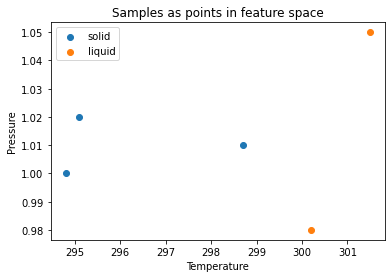

In [ ]:
import matplotlib.pyplot as plt

# One scatter call per phase, using the row filtering from section 2.4.
for phase in ["solid", "liquid"]:
    subset = materials[materials["phase"] == phase]
    plt.scatter(subset["temperature"], subset["pressure"], label=phase)

plt.xlabel("Temperature")
plt.ylabel("Pressure")
plt.title("Samples as points in feature space")
plt.legend()
plt.show()

The plot is simple, but the idea is powerful.

Each point is one row of the dataset.

The horizontal and vertical coordinates are two features.

The color indicates the target class.

Many machine learning methods can be understood as ways of finding structure in this feature space.

## 2.8 A small scientific prediction problem

The same table can be read as a prediction problem:

> Can we predict the phase of a material from temperature and pressure?

This is a **classification** problem because the target is categorical.

If the target were a continuous number, such as conductivity or energy, the problem would instead be a **regression** problem.

We will study regression and classification in the next lecture. For now, the important point is that the organization of the data already suggests what kind of machine learning problem we may want to solve.

<div class="alert alert-success">
<b>Mini-exercise 2 — Dataset anatomy</b><br>
Using the <code>materials</code> dataset above, identify:
<br><br>
1. the number of observations;<br>
2. the numerical variables;<br>
3. the categorical variables;<br>
4. the feature matrix <code>X</code>;<br>
5. the target <code>y</code>;<br>
6. whether predicting <code>phase</code> is a regression or classification problem.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 3. Loading data

In real projects, data can come from many sources:

- CSV files exported from instruments or simulations;
- Excel files;
- databases;
- web APIs;
- manually curated tables;
- output files produced by other programs.

In this course, we will mostly use **tabular data**. The most common tabular file format is CSV.

CSV means **comma-separated values**. A CSV file is just a text file where each row is one line and values are separated by commas.

For example:

```text
temperature,pressure,phase
295.1,1.02,solid
300.2,0.98,liquid
298.7,1.01,solid
```

Pandas loads CSV files using:

```python
pd.read_csv(...)
```

## 3.1 Loading a CSV file

The argument of `pd.read_csv` can be:

- a local file path, such as `"data/iris.csv"`;
- a URL pointing to a CSV file.

For classroom notebooks, URLs are convenient, but local files are more reliable.

Here we use the Iris dataset. It is small, classical, and useful for introducing both visualization and classification.

`pd.read_csv(...)` loads a CSV file and returns a pandas `DataFrame`.

The input can be a local file path or a URL.

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

iris = pd.read_csv(url)

iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


The result is a pandas `DataFrame`.

A `DataFrame` is a table with:

- row indices;
- column names;
- values;
- data types.

In this dataset, each row is one flower, and the columns contain measurements and a species label.

## 3.2 Loading data robustly

The previous cell is simple, but it depends on internet access.

For teaching, it is often safer to include a fallback.

The next version first tries to load the Iris dataset from the URL. If that fails, it loads the Iris dataset from `scikit-learn`, which is commonly installed in machine learning environments.

This pattern is useful in teaching notebooks because it avoids breaking the whole lecture because of a network problem.

In [ ]:
try:
    iris = pd.read_csv(url)
    data_source = "online CSV"
except Exception:
    from sklearn.datasets import load_iris

    bunch = load_iris(as_frame=True)
    iris = bunch.frame.rename(columns={
        "sepal length (cm)": "sepal_length",
        "sepal width (cm)": "sepal_width",
        "petal length (cm)": "petal_length",
        "petal width (cm)": "petal_width"
    })
    iris["species"] = iris["target"].map(dict(enumerate(bunch.target_names)))
    iris = iris.drop(columns="target")
    data_source = "scikit-learn fallback"

data_source

'online CSV'

## 3.3 Checking that the data loaded correctly

Loading a dataset is not enough.

Immediately after loading, we should check:

- whether the object exists;
- whether the first rows look reasonable;
- whether the column names are what we expect;
- whether the number of rows and columns makes sense.

A useful habit is:

```python
df.head()
df.shape
df.columns
```

The attribute `.columns` returns the column names. They matter because pandas operations refer to columns by name rather than by numerical position.

In [ ]:
iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

## 3.4 File paths

If the file is stored locally, the command may look like this:

```python
pd.read_csv("data/iris.csv")
```

This means:

- the notebook is in one folder;
- inside that folder there is a subfolder called `data`;
- inside `data` there is a file called `iris.csv`.

A common source of errors is that the file is not where the notebook expects it to be.

If loading fails, check:

- the file name;
- the folder name;
- spelling and capitalization;
- whether the notebook is being run from the expected directory.

<div class="alert alert-success">
<b>Mini-exercise 3 — Loading and checking data</b><br>
Using the Iris dataset loaded above:
<br><br>
1. Display the first 10 rows.<br>
2. Display the number of rows and columns.<br>
3. Display the column names.<br>
4. Identify which column could be used as a classification target.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 4. The first five minutes with a new dataset

When receiving a new dataset, experienced practitioners tend to follow a fairly consistent workflow.

The goal is not to start modelling immediately.

The goal is to answer a few basic questions:

- What does the dataset contain?
- How large is it?
- What kinds of variables does it contain?
- Are there obvious problems?
- Does anything look surprising?

A useful first habit is to run:

```python
df.head()
df.shape
df.info()
df.describe()
```

These four commands often reveal most of the information needed to begin exploring a dataset.

## 4.1 What does the dataset look like?

The first thing we usually do is inspect the first few rows.

In [ ]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Looking at the first rows helps answer several questions:

- What do the columns represent?
- Are the column names meaningful?
- Do the values look reasonable?
- Are there obvious formatting problems?

For example, the Iris dataset contains:

```text
sepal_length
sepal_width
petal_length
petal_width
species
```

Even before plotting anything, we can already recognize that:

- four columns contain measurements;
- one column contains a species label;
- the dataset is likely suitable for a classification problem.

## 4.2 How large is the dataset?

The shape tells us how many observations and variables are present.

In [ ]:
iris.shape

(150, 5)

The output

```text
(150, 5)
```

means:

```text
150 observations
5 variables
```

The first number is usually the number of rows.

The second number is usually the number of columns.

In [ ]:
len(iris)

150

`len(df)` is a useful shortcut that returns the number of rows in a DataFrame.

For the Iris dataset:

```text
150 flowers
```

were measured.

## 4.3 Looking at the extremes

Averages hide the interesting rows. To see the largest or smallest values, sort the table with
`.sort_values(column)`.

Sorting returns a **new** table; it does not reorder the original. Add `ascending=False` for
largest-first.

In [ ]:
# The five flowers with the largest petals
iris.sort_values("petal_length", ascending=False).head()

,sepal_length,sepal_width,petal_length,petal_width,species
118,7.7,2.6,6.9,2.3,virginica
122,7.7,2.8,6.7,2.0,virginica
117,7.7,3.8,6.7,2.2,virginica
105,7.6,3.0,6.6,2.1,virginica
131,7.9,3.8,6.4,2.0,virginica


In [ ]:
# The five smallest
iris.sort_values("petal_length").head()

,sepal_length,sepal_width,petal_length,petal_width,species
22,4.6,3.6,1.0,0.2,setosa
13,4.3,3.0,1.1,0.1,setosa
14,5.8,4.0,1.2,0.2,setosa
35,5.0,3.2,1.2,0.2,setosa
36,5.5,3.5,1.3,0.2,setosa


This is often the fastest way to spot a data-quality problem: an impossible value, a negative
measurement, or a placeholder such as `-999` used to mean "missing", will usually appear at one
end of a sort.

## 4.4 What types of variables do we have?

The next step is to inspect the data types.

In [ ]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


Several details are worth noticing.

Numerical measurements appear as:

```text
float64
```

This means the values are stored as double-precision floating-point numbers.

The species column appears as:

```text
object
```

In pandas, `object` often indicates text data.

This distinction is important because:

- numerical variables can be averaged, scaled and correlated;
- categorical variables usually represent labels or classes and require different treatment.

## 4.5 What ranges of values do we have?

The next command computes basic descriptive statistics.

In [ ]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


The output contains:

```text
count
mean
std
min
25%
50%
75%
max
```

where:

- `count` is the number of non-missing observations;
- `mean` is the average value;
- `std` is the standard deviation;
- `min` and `max` are the smallest and largest values;
- `50%` is the median;
- `25%` and `75%` are quartiles.

A useful mental picture is:

```text
min ---- 25% ---- median ---- 75% ---- max
```

Quartiles help describe how the data are distributed without looking at every observation individually.

## 4.6 A scientist's checklist

After running the first four commands, it is useful to pause and ask:

1. What does each row represent?
2. What does each column represent?
3. Which variables are numerical?
4. Which variables are categorical?
5. Are there missing values?
6. Do the numerical ranges look reasonable?
7. Are there obvious data-quality issues?
8. Which column could be a prediction target?

Developing this habit is often more valuable than memorizing additional pandas commands.

## 4.7 Mini case study

Using only:

```python
iris.head()
iris.info()
iris.describe()
```

what can we already infer?

Possible observations:

- the dataset contains 150 flowers;
- there are four numerical measurements;
- there is one categorical label;
- there are no obvious missing values;
- the measurements have similar numerical scales;
- the dataset appears suitable for a classification problem.

Notice that we have not yet plotted the data and we have not trained any model.

Nevertheless, we already understand much more about the dataset than we did immediately after loading it.

<div class="alert alert-success">
<b>Mini-exercise 4 — The first five minutes</b><br>
Using only:
<br><br>
<code>head()</code>, <code>shape</code>, <code>info()</code> and <code>describe()</code>
<br><br>
write down:
<br><br>
1. the number of observations;<br>
2. the number of variables;<br>
3. the numerical variables;<br>
4. the categorical variables;<br>
5. one possible machine learning task that could be performed using this dataset.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 5. Missing values

Real datasets often contain missing values.

A missing value means that an entry is absent, unknown, unavailable or not recorded.

Examples:

- a sensor failed during an experiment;
- a measurement was below the detection threshold;
- an instrument was not calibrated;
- a participant skipped a question;
- a simulation crashed for some parameter values;
- a file was merged incorrectly.

Missing values matter because many machine learning algorithms cannot use them directly.

Before modeling, we need to know whether they are present and why they are present.

## 5.1 Checking missing values

In pandas, missing values are often represented as `NaN`, meaning "Not a Number".

The standard first check is:

```python
df.isna().sum()
```

This counts how many missing values appear in each column.

The expression

```python
df.isna()
```

checks whether each entry is missing.

Combining it with

```python
.sum()
```

counts how many missing values appear in each column.

In [ ]:
iris.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

The Iris dataset is clean: all counts are zero.

Most real datasets are not this clean.

To illustrate the issue, we will create a small copy of the Iris dataset and manually insert some missing values.

The `.loc[row, column]` syntax selects entries by row label and column name.

Here we use it only to create a teaching example with artificial missing values.

In [ ]:
iris_missing = iris.copy()

iris_missing.loc[3, "sepal_length"] = np.nan
iris_missing.loc[8, "petal_width"] = np.nan
iris_missing.loc[20, "species"] = np.nan

iris_missing.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,NaN,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,NaN,setosa
9,4.9,3.1,1.5,0.1,setosa


In [ ]:
iris_missing.isna().sum()

sepal_length    1
sepal_width     0
petal_length    0
petal_width     1
species         1
dtype: int64

Now we see that three columns contain missing values.

This does not yet tell us what to do.

It only tells us where missing values are located.

## 5.2 Inspecting rows with missing values

After counting missing values, we often want to inspect the affected rows.

This helps us understand whether the missing values look isolated or systematic.

Boolean filtering is a common pandas pattern.

The inside expression creates a sequence of `True` and `False` values.

The outer expression uses that sequence to keep only the rows marked `True`.

Here, the condition means: keep rows that contain at least one missing value.

In [ ]:
iris_missing[iris_missing.isna().any(axis=1)]

,sepal_length,sepal_width,petal_length,petal_width,species
3,NaN,3.1,1.5,0.2,setosa
8,4.4,2.9,1.4,NaN,setosa
20,5.4,3.4,1.7,0.2,NaN


The expression

```python
iris_missing.isna().any(axis=1)
```

creates a Boolean value for each row:

- `True` if the row contains at least one missing value;
- `False` otherwise.

We then use this Boolean mask to select the rows with missing values.

## 5.3 Why missing values are not just a technical problem

A common beginner mistake is to treat missing values as an inconvenience to remove quickly.

But missingness can contain scientific information.

For example:

- a missing chemical measurement may indicate that a reaction failed;
- a missing medical value may indicate that a test was not ordered;
- a missing astronomical measurement may indicate that an object was too faint;
- a missing sensor reading may indicate an extreme operating condition.

In these cases, deleting missing values may remove important information.

The first question should be:

> Why is this value missing?

not:

> How do I get rid of it?

## 5.4 Common strategies

There is no universal solution for missing values.

Common strategies include:

1. **Do nothing for now**  
   Keep the missing values during exploratory analysis.

2. **Drop rows**  
   Remove observations with missing values.

3. **Drop columns**  
   Remove variables with too many missing values.

4. **Impute values**  
   Replace missing values with estimates, such as a mean, median or model-based prediction.

5. **Add a missingness indicator**  
   Create a new variable recording whether a value was missing.

Which strategy is appropriate depends on the data, the scientific question and the model.

## 5.5 Dropping missing values

The simplest strategy is to remove rows containing missing values.

This is easy, but it can discard useful data.

The method `.dropna()` removes rows containing missing values.

This is simple, but it may discard useful data.

In [ ]:
iris_missing.dropna().shape

(147, 5)

In [ ]:
iris_missing.shape

(150, 5)

In this small example, dropping missing rows removes only a few observations.

In a real dataset, it may remove a large fraction of the data.

Always check how much data is lost.

## 5.6 Simple imputation

Another simple strategy is to replace missing numerical values with the column mean or median.

This is called **imputation**.

For example, we can fill the missing `sepal_length` value with the mean sepal length.

In [ ]:
sepal_mean = iris_missing["sepal_length"].mean()

sepal_mean

5.8516778523489945

The method `.fillna(value)` replaces missing values with the value we provide.

Here we fill only one numerical column using its mean.

In [ ]:
iris_filled = iris_missing.copy()

iris_filled["sepal_length"] = iris_filled["sepal_length"].fillna(sepal_mean)

iris_filled.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     1
species         1
dtype: int64

Only the missing value in `sepal_length` was filled.

The other missing values remain because they are in different columns.

For categorical variables, filling with a numerical mean does not make sense.

This is why missing-value handling is not just a syntax issue. It requires understanding variable types.

## 5.7 A cautious rule

For this course, use the following rule:

> In exploratory analysis, detect and understand missing values.  
> In modeling, decide explicitly how to handle them.

Do not silently drop or fill missing values without recording what you did.

<div class="alert alert-success">
<b>Mini-exercise 5 — Missing values</b><br>
Using <code>iris_missing</code>:
<br><br>
1. Count missing values in each column.<br>
2. Display the rows that contain at least one missing value.<br>
3. Drop the rows with missing values and check the new shape.<br>
4. Fill the missing value in <code>petal_width</code> with the median petal width.<br>
5. Explain why filling the missing <code>species</code> value with a mean would not make sense.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 6. Basic summaries

After loading and inspecting a dataset, the next step is to summarize it.

Summaries help answer questions such as:

- How many observations belong to each category?
- What is the average value of each numerical variable?
- How much do values vary?
- Are groups different from each other?
- Do the numbers look reasonable?

This is still exploratory analysis. We are not yet fitting a model.

We are trying to understand what kind of dataset we have.

## 6.1 Summarizing categorical variables

For categorical variables, a common first question is:

> How many observations are there in each category?

For the Iris dataset, the categorical variable is `species`.

The method `.value_counts()` counts how often each value appears in a column.

This is especially useful for categorical variables.

In [ ]:
iris["species"].value_counts()

virginica     50
versicolor    50
setosa        50
Name: species, dtype: int64

The dataset contains the same number of samples for each species.

This is useful to know. Many real datasets are not balanced.

For example, a medical dataset may contain many healthy patients and only a few patients with a rare disease. A classification model trained on such data can behave very differently from a model trained on balanced data.

## 6.2 Summarizing numerical variables

For numerical variables, useful summaries include:

- mean;
- standard deviation;
- minimum;
- maximum;
- quartiles.

We already saw all of these in section 4.4, using `.describe()`.

The mean gives a typical value, while the standard deviation gives a rough measure of spread.

However, global summaries can hide important structure.

For example, if several species have different petal lengths, the global mean mixes them together.

This is why group-wise summaries are often more informative.

## 6.3 Group-wise summaries

Sometimes we want to compute summaries separately for different groups.

For example:

> What is the average petal length for each species?

This is where `groupby` becomes useful.

The `groupby` operation splits a dataset into groups, applies a calculation to each group, and combines the results.

Here we group rows by species and compute the mean of each numerical column inside each group.

In [ ]:
iris.groupby("species").mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


This table is already scientifically informative.

For example:

- `setosa` has much smaller petal length and petal width than the other species;
- `virginica` tends to have the largest petals;
- sepal measurements differ too, but the separation is less dramatic.

This suggests that petal measurements may be useful for distinguishing species.

## 6.4 Variation within groups

Means are useful, but they do not tell us how much individual samples vary within each group.

The standard deviation gives a simple measure of variation.

In [ ]:
iris.groupby("species").std()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,0.352490,0.379064,0.173664,0.105386
versicolor,0.516171,0.313798,0.469911,0.197753
virginica,0.635880,0.322497,0.551895,0.274650


A small standard deviation means that values in the group are relatively concentrated around the mean.

A large standard deviation means that values vary more widely.

When comparing groups, both the difference between means and the spread within each group matter.

Two groups may have different means but still overlap strongly if their variability is large.

## 6.5 Selecting only relevant numerical columns

Sometimes a DataFrame contains both numerical and categorical columns.

Some operations, such as computing means or correlations, should only be applied to numerical columns.

We can define a list of numerical columns and use it to select the part of the dataset we want.

In [ ]:
numeric_columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

iris[numeric_columns].head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


The expression

```python
iris[numeric_columns]
```

selects only the columns whose names are listed in `numeric_columns`.

This pattern will be useful later when we build feature matrices for machine learning.

## 6.6 Deriving a new column

Assigning to a column name that does not yet exist **creates** it. The calculation is applied to
the whole column at once, exactly like a vectorized NumPy operation.

This is the simplest form of **feature engineering**: building a new variable that expresses
something the raw measurements only imply.

In [ ]:
iris_derived = iris.copy()

iris_derived["petal_ratio"] = iris_derived["petal_length"] / iris_derived["petal_width"]
iris_derived["sepal_area"] = iris_derived["sepal_length"] * iris_derived["sepal_width"]

iris_derived.head()

,sepal_length,sepal_width,petal_length,petal_width,species,petal_ratio,sepal_area
0,5.1,3.5,1.4,0.2,setosa,7.0,17.85
1,4.9,3.0,1.4,0.2,setosa,7.0,14.70
2,4.7,3.2,1.3,0.2,setosa,6.5,15.04
3,4.6,3.1,1.5,0.2,setosa,7.5,14.26
4,5.0,3.6,1.4,0.2,setosa,7.0,18.00


A derived feature is worth building when it captures something meaningful. Here the petal ratio is
a shape descriptor: it stays roughly constant if a flower is simply larger overall, so it isolates
*proportion* from *size*.

Whether it helps is an empirical question — and we can ask it immediately, with a group-wise
summary.

In [ ]:
iris_derived.groupby("species")["petal_ratio"].mean()

species
setosa        6.908000
versicolor    3.242837
virginica     2.780662
Name: petal_ratio, dtype: float64

Always work on a copy, as above, unless you intend to modify the original table. A derived column
added by mistake to a shared dataset is a genuinely annoying bug to track down.

## 6.7 From summaries to hypotheses

Basic summaries do not prove anything, but they help us form hypotheses.

From the Iris summaries, we might hypothesize that:

- petal length and petal width are important for distinguishing species;
- setosa may be easier to separate than the other two species;
- sepal measurements may contain useful but weaker information.

The next step is to visualize these patterns.

Tables are useful, but plots often make structure much easier to see.

<div class="alert alert-success">
<b>Mini-exercise 6 — Basic summaries</b><br>
Using the Iris dataset:
<br><br>
1. Count the number of samples per species.<br>
2. Compute the mean of each numerical variable grouped by species.<br>
3. Compute the standard deviation of each numerical variable grouped by species.<br>
4. Based on these summaries, which measurements seem most useful for distinguishing the species?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 7. Visualization: distributions

Tables are useful, but they can hide structure.

A visualization can often reveal patterns that are hard to see from numerical summaries alone.

The first kind of plot we consider is the **histogram**.

A histogram shows how often values fall into different intervals.

It helps answer questions such as:

- What range of values occurs?
- Where are most observations concentrated?
- Are there unusually small or large values?
- Is the distribution symmetric or skewed?
- Are there multiple groups hidden inside the data?

## 7.1 A first histogram

Let us start with the distribution of `sepal_length`.

The command

```python
iris["sepal_length"]
```

selects one numerical column.

The method

```python
.hist(...)
```

creates a histogram of that column.

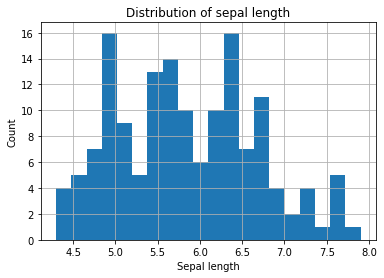

In [ ]:
iris["sepal_length"].hist(bins=20)

plt.xlabel("Sepal length")
plt.ylabel("Count")
plt.title("Distribution of sepal length")
plt.show()

The horizontal axis shows sepal length.

The vertical axis shows how many observations fall into each interval.

This plot gives more information than the mean alone.

For example, we can see:

- the approximate range of sepal lengths;
- where values are most concentrated;
- whether there are gaps or unusual values.

## 7.2 The number of bins matters

A histogram groups values into intervals called **bins**.

The number of bins affects the appearance of the plot.

Too few bins may hide structure.

Too many bins may make the plot look noisy.

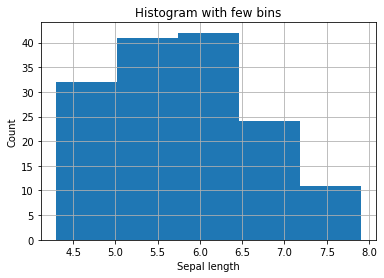

In [ ]:
iris["sepal_length"].hist(bins=5)

plt.xlabel("Sepal length")
plt.ylabel("Count")
plt.title("Histogram with few bins")
plt.show()

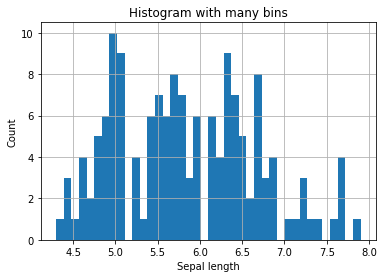

In [ ]:
iris["sepal_length"].hist(bins=40)

plt.xlabel("Sepal length")
plt.ylabel("Count")
plt.title("Histogram with many bins")
plt.show()

There is no universally correct number of bins.

A good practical habit is to try a few reasonable values and check whether the qualitative conclusion changes.

If the conclusion changes dramatically when the bin number changes, we should be cautious.

## 7.3 Comparing several variables

We can make histograms for several numerical variables.

This helps compare ranges and variability.

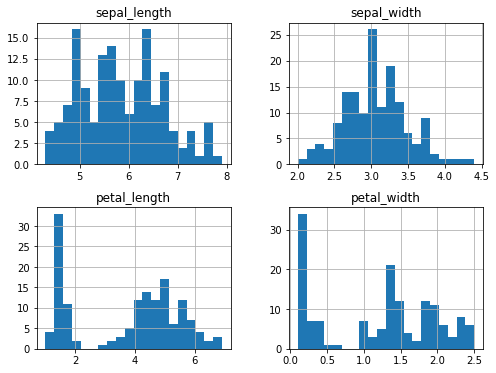

In [ ]:
iris[numeric_columns].hist(bins=20, figsize=(8, 6))

plt.show()

This compact view already suggests something important:

- sepal measurements and petal measurements have different distributions;
- petal length and petal width show stronger separation into groups;
- some variables may be more useful than others for distinguishing species.

This is exactly the kind of observation exploratory analysis is meant to produce.

## 7.4 Comparing distributions by group

The previous histograms ignored the species labels.

Sometimes we want to compare the distribution of one measurement across groups.

Here we compare petal length across species.

We can loop over the groups produced by `groupby`.

At each iteration:

- `species` is the group name;
- `group` is the part of the DataFrame corresponding to that species.

Here we use this to draw one histogram per species.

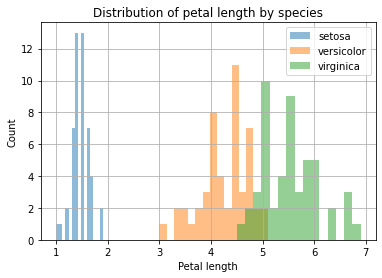

In [ ]:
for species, group in iris.groupby("species"):
    group["petal_length"].hist(alpha=0.5, bins=15, label=species)

plt.xlabel("Petal length")
plt.ylabel("Count")
plt.title("Distribution of petal length by species")
plt.legend()
plt.show()

This plot is much more informative than the global histogram.

It shows that:

- `setosa` has much smaller petal length than the other species;
- `versicolor` and `virginica` are closer to each other;
- petal length may be a strong feature for classification.

However, overlapping histograms can become hard to read when there are many groups or many variables.

Exploratory visualization is partly about choosing a plot that makes the relevant structure visible.

## 7.5 Histograms and scientific reasoning

A histogram is not just a decorative plot.

It can reveal:

- measurement ranges;
- outliers;
- multiple populations;
- skewed distributions;
- possible data-entry errors;
- differences between groups.

Before fitting a model, we should often look at the distributions of the main variables.

This is especially important in scientific data, where unexpected values may indicate either an error or an interesting phenomenon.

<div class="alert alert-success">
<b>Mini-exercise 7 — Histograms</b><br>
Using the Iris dataset:
<br><br>
1. Make a histogram of <code>petal_width</code>.<br>
2. Try at least two different values for <code>bins</code>.<br>
3. Make histograms of <code>petal_width</code> separately for each species.<br>
4. Based on the plots, does <code>petal_width</code> look useful for distinguishing species?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 8. Visualization: relationships

Histograms describe **one variable at a time**.

Much of science, however, is about **relationships between variables**.

The standard tool for looking at two numerical variables together is the **scatter plot**.

A scatter plot draws one point per observation, using one variable for the horizontal position and one for the vertical position.

It helps answer questions such as:

- Do larger values of one variable correspond to larger values of another?
- Is the relationship approximately linear, or clearly curved?
- Are there visible clusters?
- Are there outliers that do not follow the general pattern?
- How much scatter is there around the general trend?

## 8.1 A first scatter plot

The function

```python
plt.scatter(x, y)
```

takes two sequences of the same length and draws one point for each pair.

Here we plot sepal width against sepal length.

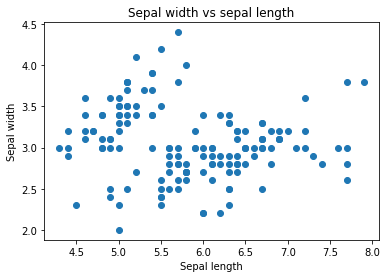

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(iris["sepal_length"], iris["sepal_width"])

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Sepal width vs sepal length")
plt.show()

Each point is one flower.

Its horizontal position is that flower's sepal length, and its vertical position is its sepal width.

Notice how little this plot resembles a clean trend. The points form a broad cloud.

If we had only computed the average sepal length and average sepal width, we would have learned almost nothing about this structure.

## 8.2 When points overlap

Scatter plots become harder to read when many points fall close together.

This is called **overplotting**: several points are drawn on top of one another, and we can no longer tell whether a region contains two observations or twenty.

Two simple remedies are:

- reduce the marker size with `s`;
- make markers partially transparent with `alpha`.

With `alpha=0.5`, a region where two points overlap appears darker than a region with a single point.

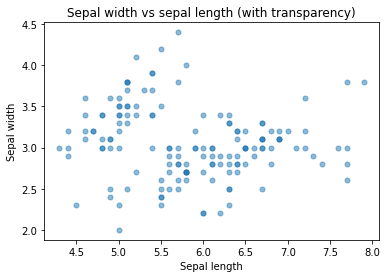

In [ ]:
plt.scatter(iris["sepal_length"], iris["sepal_width"], s=25, alpha=0.5)

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Sepal width vs sepal length (with transparency)")
plt.show()

The darker regions now indicate where observations are concentrated.

This is a small change, but it matters. In large scientific datasets, overplotting can completely hide the density structure of the data.

A useful habit: whenever a scatter plot looks like a solid block of colour, suspect overplotting.

## 8.3 Adding a third variable

A scatter plot uses two spatial dimensions, but we can encode additional variables using **colour** or **marker size**.

Here we colour each point according to its petal length.

The argument `c` sets the colour of each point, and `plt.colorbar()` adds a scale so the colours can be interpreted.

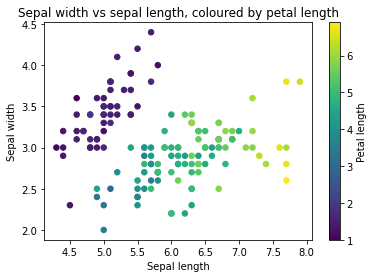

In [ ]:
scatter = plt.scatter(
    iris["sepal_length"],
    iris["sepal_width"],
    c=iris["petal_length"],
    s=30,
    cmap="viridis"
)

plt.colorbar(scatter, label="Petal length")
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Sepal width vs sepal length, coloured by petal length")
plt.show()

This plot carries three variables at once.

A structure appears that was invisible before: the flowers with small petal length occupy the upper-left region, and they seem to form a separate group.

This is a good illustration of a general principle:

> Structure that is invisible in one projection of the data may become obvious in another.

Encoding works, but it has limits. Colour is much harder to read quantitatively than position, and adding a fourth or fifth encoded variable usually produces an unreadable plot.

## 8.4 Looking at all pairs at once

With four numerical variables there are six possible pairs.

Rather than making six plots by hand, pandas can produce a **scatter matrix**: a grid showing every variable against every other.

The diagonal shows the distribution of each individual variable.

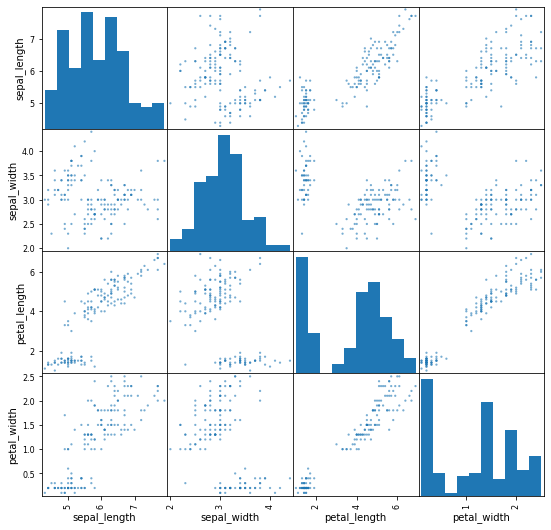

In [ ]:
from pandas.plotting import scatter_matrix

scatter_matrix(
    iris[numeric_columns],
    figsize=(9, 9),
    diagonal="hist",
    alpha=0.6,
    s=20
)

plt.show()

This single figure is a compact summary of the whole dataset.

Reading it row by row, we can already see that:

- `petal_length` and `petal_width` are strongly related to each other;
- both petal variables show a clear gap, suggesting two separate groups;
- `sepal_width` shows much less structure than the other variables;
- `sepal_length` is related to the petal measurements.

A scatter matrix is often the single most informative first plot for a small tabular dataset.

## 8.5 How scatter plots can mislead

A scatter plot is an interpretation, not a neutral record of the data.

The same points can suggest different conclusions depending on the axis ranges.

The two plots below show **exactly the same data**, with different vertical limits.

The call `plt.subplots(1, 2)` creates one figure containing a grid of plots — here one row of two.
It returns the figure and an array of axes, one per panel, and each panel is then drawn on
separately with `ax.scatter(...)` rather than `plt.scatter(...)`.

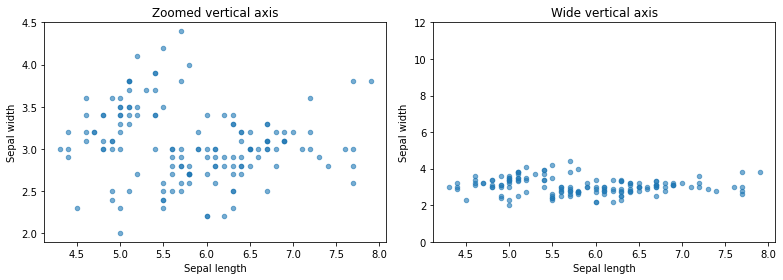

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, ylim, title in zip(
    axes,
    [(1.9, 4.5), (0.0, 12.0)],
    ["Zoomed vertical axis", "Wide vertical axis"]
):
    ax.scatter(iris["sepal_length"], iris["sepal_width"], s=20, alpha=0.6)
    ax.set_ylim(ylim)
    ax.set_xlabel("Sepal length")
    ax.set_ylabel("Sepal width")
    ax.set_title(title)

plt.tight_layout()
plt.show()

On the left the data look spread out and variable.

On the right they look tightly clustered and almost constant.

Neither plot is wrong, but they invite different conclusions.

When reading a plot, whether your own or someone else's, always check the axis ranges before forming an impression.

<div class="alert alert-success">
<b>Mini-exercise 8 — Scatter plots</b><br>
Using the Iris dataset:
<br><br>
1. Make a scatter plot of <code>petal_length</code> against <code>petal_width</code>.<br>
2. Add transparency and reduce the marker size.<br>
3. Colour the points by <code>sepal_length</code> and add a colour bar.<br>
4. Compare this plot with the sepal scatter plot from Section 8.1. Which pair of variables shows more structure?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 9. Visualization: groups

Many scientific datasets contain a **categorical label** in addition to numerical measurements:

- a species;
- a material class;
- an experimental condition;
- a detector state;
- a diagnosis.

When such a label exists, one of the most useful things we can do is look at whether the numerical measurements differ between groups.

This is the exploratory step that comes immediately before classification.

## 9.1 Why group structure matters

In Section 8.3 we saw a hint of separate groups when colouring by petal length.

The Iris dataset actually tells us the answer directly, because it contains a `species` column.

If the groups occupy clearly different regions of the plot, then a classification model is likely to succeed.

If the groups overlap completely, then either the measurements do not contain the relevant information, or we need different features.

This is worth emphasising:

> Looking at group separation before modelling tells us whether the modelling problem is likely to be easy, hard, or impossible with the available measurements.

## 9.2 Colouring points by group

We can loop over the groups produced by `groupby`.

At each iteration:

- `species` is the group name;
- `group` is the part of the DataFrame corresponding to that species.

Calling `plt.scatter` once per group means each group receives its own colour and its own legend entry.

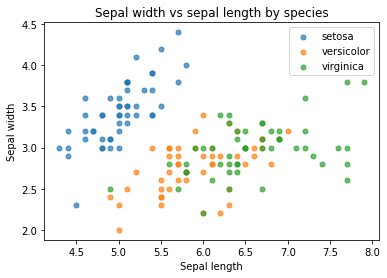

In [ ]:
for species, group in iris.groupby("species"):
    plt.scatter(group["sepal_length"], group["sepal_width"], label=species, s=25, alpha=0.7)

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Sepal width vs sepal length by species")
plt.legend()
plt.show()

The shapeless cloud from Section 8.1 now has structure.

`setosa` occupies the upper-left region and is fairly well separated.

`versicolor` and `virginica` overlap substantially in these two variables.

So the sepal measurements alone would let us identify `setosa` reliably, but would struggle to distinguish the other two species.

## 9.3 Box plots by group

A scatter plot shows individual observations.

Sometimes we want a compact summary of **one variable across several groups**. A **box plot** does this.

The syntax

```python
iris.boxplot(column="petal_length", by="species")
```

means: summarise the column `petal_length`, split by the values of `species`.

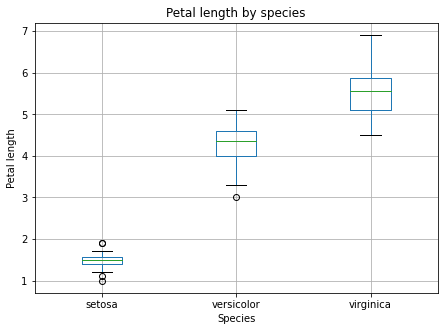

In [ ]:
iris.boxplot(column="petal_length", by="species", figsize=(7, 5))

plt.xlabel("Species")
plt.ylabel("Petal length")
plt.title("Petal length by species")
plt.suptitle("")
plt.show()

The extra call `plt.suptitle("")` simply removes the automatic title that pandas adds above the figure.

### Reading a box plot

Each box summarises the distribution of one group:

- the **line inside the box** is the median;
- the **box** spans the middle 50% of the data, from the 25th to the 75th percentile;
- the **whiskers** run out to the most distant observations that are not judged unusual;
- **individual points** beyond the whiskers are flagged as potential outliers.

Those descriptions are hard to picture from words alone. The figure below takes a single group —
the 50 versicolor flowers — and puts its box plot next to a histogram of the very same numbers,
turned on its side so that the two share a vertical axis.

Every feature of the box is drawn from the histogram beside it.

In [ ]:
versicolor = iris[iris["species"] == "versicolor"]["petal_length"]

# The five numbers a box plot is built from
q1, median, q3 = versicolor.quantile([0.25, 0.50, 0.75])
iqr = q3 - q1
lower_fence, upper_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
lower_whisker = versicolor[versicolor >= lower_fence].min()
upper_whisker = versicolor[versicolor <= upper_fence].max()
outliers = versicolor[(versicolor < lower_fence) | (versicolor > upper_fence)]

print(f"1.5 x IQR      {1.5 * iqr:.2f}")
print(f"lower fence    {lower_fence:.2f}   (Q1 - 1.5 x IQR)")
print(f"upper fence    {upper_fence:.2f}   (Q3 + 1.5 x IQR)")
print()
print(f"lower whisker  {lower_whisker:.2f}")
print(f"Q1  (25%)      {q1:.2f}")
print(f"median (50%)   {median:.2f}")
print(f"Q3  (75%)      {q3:.2f}")
print(f"upper whisker  {upper_whisker:.2f}")
print(f"IQR = Q3 - Q1  {iqr:.2f}")
print(f"outliers       {sorted(outliers.tolist())}")

1.5 x IQR      0.90
lower fence    3.10   (Q1 - 1.5 x IQR)
upper fence    5.50   (Q3 + 1.5 x IQR)

lower whisker  3.30
Q1  (25%)      4.00
median (50%)   4.35
Q3  (75%)      4.60
upper whisker  5.10
IQR = Q3 - Q1  0.60
outliers       [3.0]


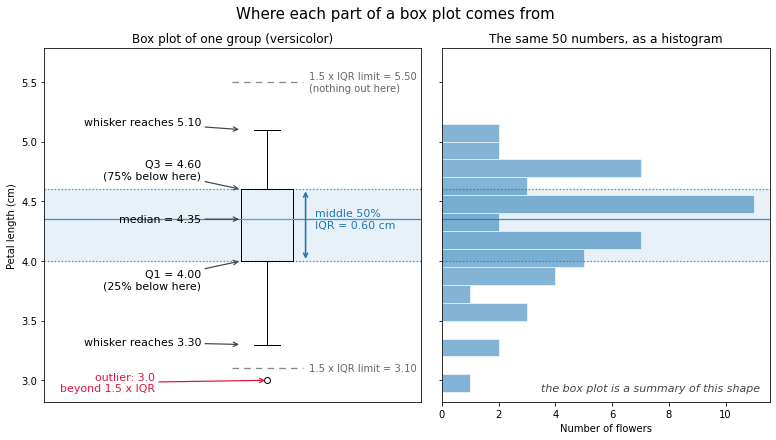

In [ ]:
fig, (ax_box, ax_hist) = plt.subplots(
    1, 2, figsize=(13, 6.5), sharey=True,
    gridspec_kw={"width_ratios": [1.15, 1.0], "wspace": 0.06})

# ---- shared horizontal guides, so the eye can carry each level across ----
for ax in (ax_box, ax_hist):
    ax.axhspan(q1, q3, color="tab:blue", alpha=0.10)
    for level, style in [(q1, ":"), (median, "-"), (q3, ":")]:
        ax.axhline(level, color="tab:blue", linestyle=style, linewidth=1.3, alpha=0.8)

# ---- left: the box plot itself ----
ax_box.boxplot(versicolor, positions=[1.45], widths=0.34, vert=True)
ax_box.set_xlim(0, 2.45)
ax_box.set_xticks([])
ax_box.set_ylim(2.82, 5.78)
ax_box.set_ylabel("Petal length (cm)")
ax_box.set_title("Box plot of one group (versicolor)")

def label(text, y, x_text, y_text=None):
    ax_box.annotate(text, xy=(1.28, y), xytext=(x_text, y_text if y_text else y),
                    fontsize=11, ha="right", va="center",
                    arrowprops={"arrowstyle": "->", "linewidth": 1.2, "color": "#444"})

label(f"median = {median:.2f}", median, 1.02)
label(f"Q3 = {q3:.2f}\n(75% below here)", q3, 1.02, q3 + 0.16)
label(f"Q1 = {q1:.2f}\n(25% below here)", q1, 1.02, q1 - 0.16)
label(f"whisker reaches {upper_whisker:.2f}", upper_whisker, 1.02, upper_whisker + 0.06)
label(f"whisker reaches {lower_whisker:.2f}", lower_whisker, 1.02, lower_whisker + 0.02)
ax_box.annotate(f"outlier: {outliers.iloc[0]:.1f}\nbeyond 1.5 x IQR", xy=(1.45, outliers.iloc[0]),
                xytext=(0.72, outliers.iloc[0] - 0.02), fontsize=11, ha="right", va="center",
                color="crimson",
                arrowprops={"arrowstyle": "->", "linewidth": 1.2, "color": "crimson"})

# the 1.5 x IQR limits: a calculation, not something a box plot normally shows
for fence in (lower_fence, upper_fence):
    ax_box.hlines(fence, 1.22, 1.68, color="#888", linestyle=(0, (5, 4)), linewidth=1.3)
ax_box.text(1.72, upper_fence, f"1.5 x IQR limit = {upper_fence:.2f}\n(nothing out here)",
            fontsize=10, va="center", color="#666")
ax_box.text(1.72, lower_fence, f"1.5 x IQR limit = {lower_fence:.2f}",
            fontsize=10, va="center", color="#666")

# the box itself spans the middle half of the data
ax_box.annotate("", xy=(1.70, q1), xytext=(1.70, q3),
                arrowprops={"arrowstyle": "<->", "linewidth": 1.6, "color": "tab:blue"})
ax_box.text(1.76, median, f"middle 50%\nIQR = {iqr:.2f} cm",
            fontsize=11, va="center", color="tab:blue")

# ---- right: the same numbers as a histogram, lying on its side ----
bins = np.arange(2.9, 5.35, 0.15)
ax_hist.hist(versicolor, bins=bins, orientation="horizontal",
             color="tab:blue", alpha=0.55, edgecolor="white")
ax_hist.set_xlabel("Number of flowers")
ax_hist.set_title("The same 50 numbers, as a histogram")
ax_hist.text(0.97, 0.03, "the box plot is a summary of this shape",
             transform=ax_hist.transAxes, ha="right", fontsize=11, style="italic", color="#444")

fig.suptitle("Where each part of a box plot comes from", fontsize=15, y=0.97)
plt.show()

Read the two panels together.

The shaded band is the **box**: it starts at Q1 and ends at Q3, and the histogram shows that
exactly half the flowers fall inside it. The solid line across both panels is the **median**, with
25 flowers above and 25 below.

The **whiskers** reach out to the most extreme values that are still within 1.5 interquartile
ranges of the box. Everything beyond that is drawn as an individual point: here one flower with a
petal length of 3.0 cm, visible in the histogram as the isolated bar on the far left.

The 1.5 is a convention, not a law, and a point beyond it is a **candidate** for investigation
rather than an error. In this case 3.0 cm is a perfectly plausible petal.

### How far do the whiskers actually reach?

The rule has two steps, and the second is the one that catches people out.

**First**, compute a limit at one and a half interquartile ranges beyond each end of the box. These
limits are usually called **fences**:

$$
\text{lower fence} = Q_1 - 1.5 \times \text{IQR} = 4.00 - 0.90 = 3.10
$$
$$
\text{upper fence} = Q_3 + 1.5 \times \text{IQR} = 4.60 + 0.90 = 5.50
$$

**Second — and this is the part that surprises people — the whisker does not extend to the fence.**
It stops at the most extreme observation that still lies inside it.

Here the smallest petal at or above 3.10 cm measures **3.30**, and the largest at or below 5.50 cm
measures **5.10**. Those are where the whiskers end, 0.20 cm and 0.40 cm short of the fences. The
fences are drawn as grey dashes in the figure so that the gap is visible; a real box plot never
shows them.

Three consequences follow.

- **Whisker length is not fixed.** Two groups with the same box can have very different whiskers,
  because the whiskers are set by where the data happen to stop.
- **A whisker well short of its fence means the data simply run out there**, not that anything was
  excluded.
- **Anything beyond a fence is drawn individually** rather than being absorbed into a whisker.
  That is the single flower at 3.0 cm.

The whiskers therefore carry real information about the range of the data, while remaining immune
to a single extreme value dragging them out — which is exactly what the mean and standard
deviation fail to do, as the pitfalls in section 12 show.

The comparison also makes the box plot's main weakness visible.

The histogram shows the *shape* of the distribution. The box plot keeps only five numbers from it.
Those five are enough to compare many groups at a glance, which is exactly what section 9.3's plot
did for three species at once — but a distribution split into two separate humps would produce a
perfectly ordinary-looking box, and you would never know.

> Use a box plot to compare groups. Use a histogram to understand one.

## 9.4 Choosing between plot types

Different questions call for different plots.

| Question | Suitable plot |
|---|---|
| How is one variable distributed? | Histogram |
| How do two variables relate? | Scatter plot |
| How does one variable differ across groups? | Box plot, or overlaid histograms |
| Do groups separate in two variables? | Scatter plot coloured by group |
| Which variables relate to which? | Scatter matrix, correlation heatmap |

There is no single correct plot. The useful question is always:

> What do I want to find out, and which plot would make that visible?

<div class="alert alert-success">
<b>Mini-exercise 9 — Group comparison</b><br>
Using the Iris dataset:
<br><br>
1. Create a scatter plot of <code>petal_length</code> versus <code>petal_width</code>, with one colour per species.<br>
2. Create a box plot of <code>sepal_width</code> by species.<br>
3. Compare the petal scatter plot with the sepal scatter plot in Section 9.2.<br>
4. Which pair of measurements would you choose if you had to distinguish the three species? Why?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 10. Correlation

Plots are powerful, but we sometimes want a **number** that summarises how strongly two variables are related.

The most common such number is the **correlation coefficient**.

## 10.1 What correlation measures

For two variables $x$ and $y$ with $n$ observations, the Pearson correlation coefficient is

$$
r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}
         {\sqrt{\sum_i (x_i - \bar{x})^2}\;\sqrt{\sum_i (y_i - \bar{y})^2}}
$$

The value always lies between $-1$ and $+1$:

- $r$ close to $+1$: a strong **positive linear** relationship;
- $r$ close to $-1$: a strong **negative linear** relationship;
- $r$ close to $0$: little or no **linear** relationship.

The word *linear* is doing a great deal of work in those statements, and Section 10.3 shows why.

Note also that $r$ is dimensionless and unaffected by the units of measurement. Converting from centimetres to millimetres does not change the correlation.

## 10.2 The correlation matrix

The method `.corr()` computes the correlation between every pair of numerical columns.

The result is a **correlation matrix**: symmetric, with ones on the diagonal, since every variable is perfectly correlated with itself.

In [ ]:
numeric_columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

iris[numeric_columns].corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


Reading this table:

- `petal_length` and `petal_width` have correlation about $0.96$, which is very strong;
- `sepal_length` correlates strongly with both petal measurements, about $0.87$ and $0.82$;
- `sepal_width` correlates weakly and *negatively* with everything else.

This matches what the scatter matrix showed in Section 8.4, but now with numbers attached.

The very high correlation between the two petal variables is worth noticing. It means they carry largely **redundant** information. Later in the course, when we study dimensionality reduction, this redundancy is exactly what we will exploit.

## 10.3 Visualizing the correlation matrix

For four variables the table is easy to read.

For fifty variables it is not. A **heatmap** makes the structure visible at a glance.

We use a diverging colour map centred on zero, so that positive and negative correlations are visually distinct.

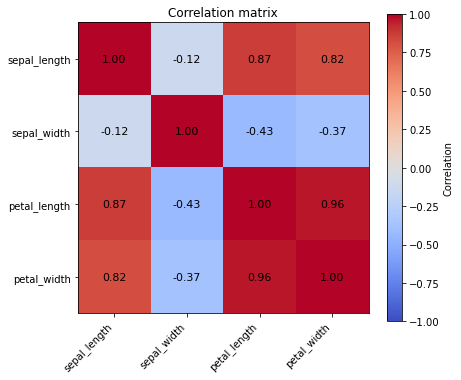

In [ ]:
import numpy as np

corr = iris[numeric_columns].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
image = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(numeric_columns)))
ax.set_yticks(range(len(numeric_columns)))
ax.set_xticklabels(numeric_columns, rotation=45, ha="right")
ax.set_yticklabels(numeric_columns)

# Write the numerical value inside each cell
for i in range(len(numeric_columns)):
    for j in range(len(numeric_columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=11)

fig.colorbar(image, label="Correlation")
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()

The block of warm colours in the lower right corner immediately shows the group of mutually correlated variables.

The cool row and column for `sepal_width` show that it behaves differently from the rest.

For datasets with many variables, this kind of plot is often the fastest way to spot redundant measurements.

## 10.4 Correlation only captures linear relationships

A correlation near zero does **not** mean the variables are unrelated.

It means they are not *linearly* related.

The example below constructs a perfect parabolic relationship, where $y$ is completely determined by $x$.

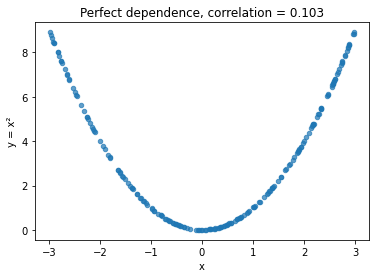

In [ ]:
rng = np.random.default_rng(0)

x = rng.uniform(-3, 3, 200)
y = x ** 2

plt.scatter(x, y, s=20, alpha=0.7)
plt.xlabel("x")
plt.ylabel("y = x²")
plt.title(f"Perfect dependence, correlation = {np.corrcoef(x, y)[0, 1]:.3f}")
plt.show()

The correlation is essentially zero, yet $y$ is a deterministic function of $x$.

Any analysis that screened variables purely by correlation would discard $x$ as uninformative, even though it predicts $y$ perfectly.

This is a genuine hazard in scientific data analysis. The lesson is simple:

> Always plot the data. Never rely on a correlation coefficient alone.

## 10.5 Grouping can reverse a correlation

Here is a more subtle effect, and one that appears in the Iris data itself.

Let us compute the correlation between sepal length and sepal width for the whole dataset, and then separately within each species.

In [ ]:
overall = iris["sepal_length"].corr(iris["sepal_width"])
print(f"Overall correlation:  {overall:.3f}")

print("\nWithin each species:")
for species, group in iris.groupby("species"):
    r = group["sepal_length"].corr(group["sepal_width"])
    print(f"  {species:12s} {r:+.3f}")

Overall correlation:  -0.118

Within each species:
  setosa       +0.743
  versicolor   +0.526
  virginica    +0.457


The overall correlation is slightly **negative**, about $-0.12$.

Within every single species it is clearly **positive**, between about $+0.46$ and $+0.74$.

So the relationship reverses sign depending on whether we account for species.

This phenomenon is known as **Simpson's paradox**. It happens because the three species have different average sepal lengths and widths, and mixing them together creates a spurious overall trend that contradicts the trend inside each group.

The plot below makes it visible. To draw the trend inside each group we use
`np.polyfit(x, y, 1)`, which fits a straight line by least squares and returns its slope and
intercept. We will meet that fit properly in the next class; here it is only a drawing tool.

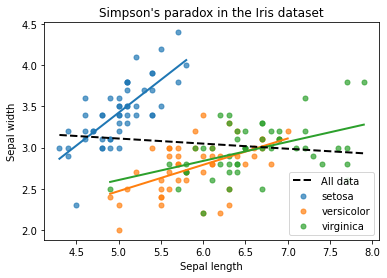

In [ ]:
for species, group in iris.groupby("species"):
    plt.scatter(group["sepal_length"], group["sepal_width"], label=species, s=25, alpha=0.7)

    # Fit and draw a straight line within this species
    slope, intercept = np.polyfit(group["sepal_length"], group["sepal_width"], 1)
    xs = np.linspace(group["sepal_length"].min(), group["sepal_length"].max(), 10)
    plt.plot(xs, slope * xs + intercept, linewidth=2)

# Straight line fitted to all the data together
slope, intercept = np.polyfit(iris["sepal_length"], iris["sepal_width"], 1)
xs = np.linspace(iris["sepal_length"].min(), iris["sepal_length"].max(), 10)
plt.plot(xs, slope * xs + intercept, "k--", linewidth=2, label="All data")

plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title("Simpson's paradox in the Iris dataset")
plt.legend()
plt.show()

The three coloured lines all slope upwards. The black dashed line, fitted to everything at once, slopes downwards.

The practical consequence for scientific work is serious. If a dataset contains distinct sub-populations, an aggregate statistic can point in the opposite direction from the truth within every sub-population.

Whenever a dataset contains groups, ask whether the analysis should be done within groups.

## 10.6 Correlation is not causation

Two variables can be strongly correlated for several distinct reasons:

- $x$ influences $y$;
- $y$ influences $x$;
- a third variable influences both (a **confounder**);
- the sample was selected in a way that induces a relationship;
- coincidence, especially with few observations or many variables tested.

In the Iris data, petal length and petal width are strongly correlated, but neither causes the other. Both are consequences of the flower's species and size.

Correlation restricts the set of plausible explanations. It does not select among them.

<div class="alert alert-success">
<b>Mini-exercise 10 — Correlation</b><br>
Using the Iris dataset:
<br><br>
1. Compute the correlation matrix separately for each species, using <code>groupby</code>.<br>
2. Compare these with the overall correlation matrix from Section 10.2.<br>
3. Are there other pairs of variables, besides sepal length and width, whose correlation changes noticeably when species is taken into account?<br>
4. Explain in one or two sentences why this happens.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 11. Mini case study: can species be distinguished?

We now put the tools of this notebook together.

Without fitting any machine learning model, we can already ask a question that sounds like a modelling question:

> Do the measurements contain enough structure to distinguish the three species?

If the answer is clearly yes, a classifier will probably work well. If the answer is no, no amount of modelling will rescue us, and we need better measurements instead.

This is the value of exploratory analysis: it tells us what to expect before we spend effort on models.

## 11.1 Group-wise averages

We start with the simplest possible summary: the mean of each measurement within each species.

In [ ]:
iris.groupby("species")[numeric_columns].mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


The petal measurements differ dramatically between species. Petal length rises from roughly 1.5 to 4.3 to 5.6.

The sepal measurements differ much less, and `sepal_width` barely differs at all.

This is a first indication that the petal measurements carry most of the useful information.

## 11.2 Visual separation

Means alone can be misleading, because two groups with different means may still overlap heavily if their spread is large.

So we look at the actual points.

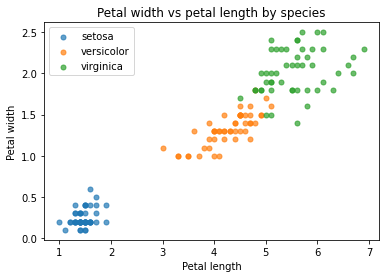

In [ ]:
for species, group in iris.groupby("species"):
    plt.scatter(group["petal_length"], group["petal_width"], label=species, s=25, alpha=0.7)

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title("Petal width vs petal length by species")
plt.legend()
plt.show()

This is a much clearer picture than any of the sepal plots.

`setosa` is completely separated from the others, with a wide empty gap.

`versicolor` and `virginica` form distinct groups that touch at their boundary but overlap only slightly.

A simple rule of the form "if petal length is below 2.5, predict setosa" would already classify one species perfectly.

## 11.3 Quantifying separation

"Clearly separated" is a visual impression. Can we attach a number to it?

A simple approach is to compare two quantities for each measurement:

- how much the **group means** differ from one another (the between-group spread);
- how much the values **vary within** each group (the within-group spread).

A measurement is useful for distinguishing groups when the first is large compared to the second.

In [ ]:
print(f"{'variable':16s} {'between':>9s} {'within':>9s} {'ratio':>8s}")
print("-" * 45)

for column in numeric_columns:
    group_means = iris.groupby("species")[column].mean()
    group_stds = iris.groupby("species")[column].std()

    between = group_means.std()      # spread of the group means
    within = group_stds.mean()       # typical spread inside a group

    print(f"{column:16s} {between:9.2f} {within:9.2f} {between / within:8.2f}")

variable           between    within    ratio
---------------------------------------------
sepal_length          0.80      0.50     1.59
sepal_width           0.34      0.34     1.00
petal_length          2.09      0.40     5.25
petal_width           0.90      0.19     4.66


The ratios rank the measurements clearly:

- `petal_length` — about 5.2
- `petal_width` — about 4.7
- `sepal_length` — about 1.6
- `sepal_width` — about 1.0

The petal measurements are three to five times more discriminative than the sepal measurements.

This confirms the visual impression numerically, and it is a simplified version of an idea we will meet again: assessing how informative a feature is before, or instead of, using it in a model.

## 11.4 What we learned without fitting a model

Using only loading, summarising and plotting, we have established that:

- the dataset has 150 rows, 4 numerical measurements and 1 categorical label;
- there are no missing values;
- the three species are balanced, 50 samples each;
- petal measurements separate the species well; sepal measurements do not;
- `setosa` is perfectly separable; `versicolor` and `virginica` overlap slightly;
- petal length and petal width are highly redundant with each other.

Every one of these findings would shape how we approach a model.

The last point in particular predicts something specific: since a single well-chosen measurement nearly determines the species, a very simple classifier should perform almost as well as a complicated one.

This naturally motivates the next part of the course:

> Can we build a model that automatically predicts the species from the measurements, and how would we know whether it is any good?

# 12. Common pitfalls

The nine mistakes below are common, and all of them have appeared in published scientific work.

Three of them can be shown rather than described, so those three carry a figure. That is a
difference in how easily each one is demonstrated, not in how much it matters.

## 12.1 Assuming the data loaded correctly

A file may load without raising an error and still be wrong: the wrong separator, a header row
treated as data, numbers read as text, or silently truncated rows. Always inspect shape, types and
a few rows after loading.

## 12.2 Ignoring missing values

Missing entries are rarely missing at random. Instruments fail under particular conditions, and
measurements below a detection threshold are often recorded as blank. Dropping them silently can
bias a whole analysis.

## 12.3 Confusing rows and columns

Rows are observations; columns are variables. Transposing the two produces results that look
plausible and are meaningless.

## 12.4 Trusting summary statistics alone

A mean tells us nothing about shape, spread, groups or outliers.

The classic demonstration is **Anscombe's quartet**: four datasets constructed so that their
summary statistics agree to two decimal places. Same mean in each variable, same standard
deviation, same correlation, and the same fitted straight line.

In [ ]:
anscombe_x = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], dtype=float)
anscombe_x4 = np.array([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8], dtype=float)

quartet = {
    "I":   (anscombe_x,  np.array([8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68])),
    "II":  (anscombe_x,  np.array([9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74])),
    "III": (anscombe_x,  np.array([7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73])),
    "IV":  (anscombe_x4, np.array([6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])),
}

print(f"{'set':5}{'mean x':>9}{'mean y':>9}{'sd x':>8}{'sd y':>8}{'corr':>8}")
for name, (x_values, y_values) in quartet.items():
    print(f"{name:5}{x_values.mean():>9.2f}{y_values.mean():>9.2f}"
          f"{x_values.std(ddof=1):>8.2f}{y_values.std(ddof=1):>8.2f}"
          f"{np.corrcoef(x_values, y_values)[0, 1]:>8.3f}")

set     mean x   mean y    sd x    sd y    corr
I         9.00     7.50    3.32    2.03   0.816
II        9.00     7.50    3.32    2.03   0.816
III       9.00     7.50    3.32    2.03   0.816
IV        9.00     7.50    3.32    2.03   0.817


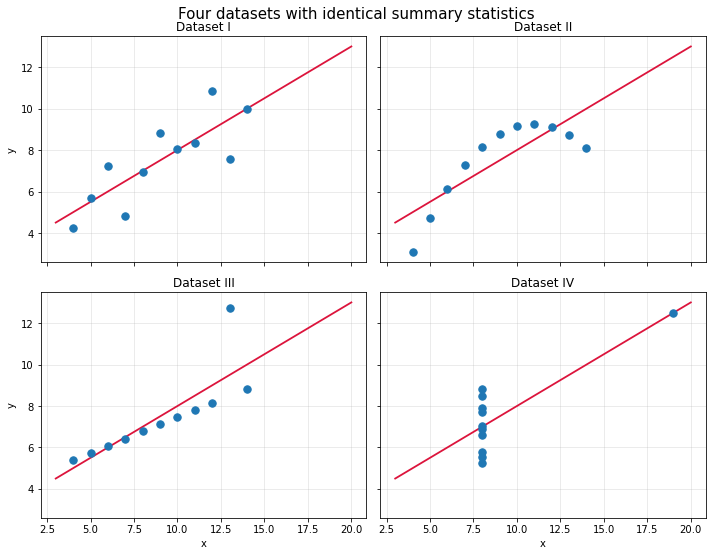

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

for ax, (name, (x_values, y_values)) in zip(axes.ravel(), quartet.items()):
    ax.scatter(x_values, y_values, s=55, zorder=3)

    # Every one of the four is fitted by exactly the same straight line.
    line_x = np.linspace(3, 20, 10)
    ax.plot(line_x, 3.0 + 0.5 * line_x, color="crimson", linewidth=1.8, zorder=2)

    ax.set_title(f"Dataset {name}", fontsize=12)
    ax.grid(alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("y")

fig.suptitle("Four datasets with identical summary statistics", fontsize=15, y=0.96)
plt.tight_layout()
plt.show()

The four are nothing alike.

**I** is a genuine noisy linear relationship, and the fitted line is a fair summary of it.
**II** is a clean curve, and a straight line is simply the wrong shape.
**III** is perfectly linear apart from one aberrant point, which drags the line away from every
other observation.
**IV** contains no relationship at all: ten flowers at the same $x$, and one distant point that
invents a slope single-handedly.

Any analysis that reported only "mean 9.00 and 7.50, correlation 0.82, slope 0.50" would describe
all four identically, and would be badly misleading about three of them.

> Plot the data. Summary statistics are a compression, and compression loses things.

## 12.5 Interpreting correlation as causation

A correlation constrains the set of explanations; it does not choose among them. Section 10.4 also
showed the converse trap: near-zero correlation does not mean the variables are unrelated.

## 12.6 Ignoring group structure

As section 10.5 showed, an aggregate trend can reverse within every subgroup.

## 12.7 Plotting without labels

An unlabelled plot is not interpretable by a reader, and after two weeks it is not interpretable
by its author either.

Both panels below show exactly the same data.

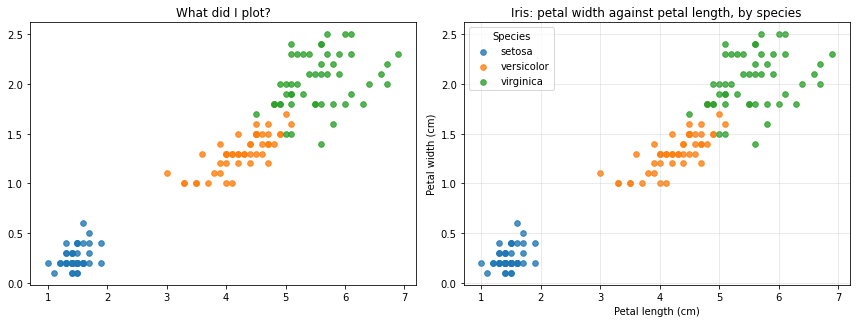

In [ ]:
fig, (bare, labelled) = plt.subplots(1, 2, figsize=(12, 4.6))

for ax in (bare, labelled):
    for species, group in iris.groupby("species"):
        ax.scatter(group["petal_length"], group["petal_width"], s=32, alpha=0.8, label=species)

bare.set_title("What did I plot?")

labelled.set_xlabel("Petal length (cm)")
labelled.set_ylabel("Petal width (cm)")
labelled.set_title("Iris: petal width against petal length, by species")
labelled.legend(title="Species")
labelled.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The left panel is not wrong. It is simply useless to anyone who was not in the room when it was
made — including you, later. Axis labels, units, and a legend cost seconds.

## 12.8 Choosing a plot that obscures the structure

Overplotted scatter plots and misleading axis ranges were covered in section 8. The most common
offender in published work, though, is the bar chart of group means.

The three groups below have been constructed to have **exactly the same mean**.

In [ ]:
rng = np.random.default_rng(7)

group_a = rng.normal(10.0, 0.4, 40)                                    # one tight cluster
group_b = np.concatenate([rng.normal(8.2, 0.35, 20),
                          rng.normal(11.8, 0.35, 20)])                 # two separate humps
group_c = np.concatenate([rng.normal(9.3, 0.3, 37),
                          rng.normal(19.0, 0.4, 3)])                   # a cluster plus extremes

# Shift each to exactly the same mean, so the bars are provably identical.
groups = {name: values - values.mean() + 10.0
          for name, values in [("A", group_a), ("B", group_b), ("C", group_c)]}

for name, values in groups.items():
    print(f"group {name}:  mean = {values.mean():.2f}   std = {values.std(ddof=1):.2f}")

group A:  mean = 10.00   std = 0.33
group B:  mean = 10.00   std = 1.81
group C:  mean = 10.00   std = 2.62


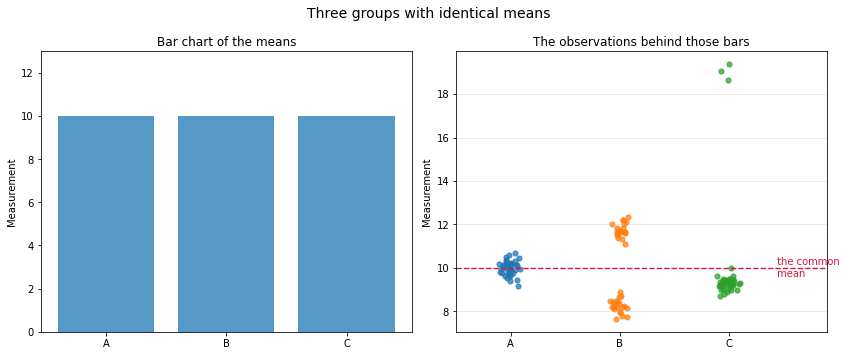

In [ ]:
fig, (bars, points) = plt.subplots(1, 2, figsize=(12, 5))

bars.bar(list(groups), [v.mean() for v in groups.values()], color="tab:blue", alpha=0.75)
bars.set_ylabel("Measurement")
bars.set_title("Bar chart of the means")
bars.set_ylim(0, 13)

for offset, (name, values) in enumerate(groups.items()):
    jitter = rng.normal(0, 0.05, len(values))
    points.scatter(np.full(len(values), offset) + jitter, values, s=26, alpha=0.75)

points.axhline(10.0, color="crimson", linewidth=1.4, linestyle="--")
points.text(2.42, 10.0, " the common\n mean", color="crimson", fontsize=10, va="center")

points.set_xticks(range(len(groups)))
points.set_xticklabels(list(groups))
points.set_ylabel("Measurement")
points.set_title("The observations behind those bars")
points.grid(alpha=0.3, axis="y")
points.set_xlim(-0.5, 2.9)

fig.suptitle("Three groups with identical means", fontsize=14)
plt.tight_layout()
plt.show()

The bar chart shows three identical rectangles, and would support the conclusion that the groups
are indistinguishable.

They are nothing of the sort. **A** is a single tight cluster. **B** is two separated populations
with almost nobody at the mean itself — the bar marks a value that barely occurs. **C** is a tight
cluster plus three extreme observations that carry the average upwards on their own.

A bar chart of means shows one number per group and hides everything else. Show the observations,
or at least a box plot, whenever there is room.

## 12.9 Modelling before understanding the data

This is the most expensive mistake, because it can waste weeks. Time spent on exploratory analysis
is almost always recovered.

# 13. Final exercises

<div class="alert alert-success">
<b>Exercise 1 — First exploratory report</b><br>
Write a short exploratory report on the Iris dataset.
<br><br>
Your report should include:
<br><br>
1. number of rows and columns;<br>
2. column names and data types;<br>
3. number of samples per species;<br>
4. mean values grouped by species;<br>
5. one histogram;<br>
6. one scatter plot;<br>
7. two or three sentences describing what you observe.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — Relationship between variables</b><br>
Investigate the relationship between petal length and petal width.
<br><br>
1. Make a scatter plot.<br>
2. Compute the correlation between the two variables.<br>
3. Compute the correlation again separately within each species.<br>
4. Comment on whether the relationship appears weak, moderate or strong, and on whether it changes when species is taken into account.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — A new dataset</b><br>
Apply the whole workflow of this notebook to a dataset you have not seen before.
<br><br>
Load the penguins dataset:
<br><br>
<code>url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"</code>
<br><br>
Then:
<br><br>
1. Inspect its shape, columns and data types.<br>
2. Check for missing values and decide how to handle them, explaining your choice.<br>
3. Identify which columns are numerical and which are categorical.<br>
4. Produce at least one histogram, one scatter plot coloured by species, and a correlation matrix.<br>
5. Using the ratio idea from Section 11.3, decide which measurements best distinguish the species.<br>
6. Write three sentences summarising what you would tell a collaborator about this dataset.
<br><br>
This dataset is messier than Iris. That is the point.
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key takeaways

- Data exploration comes before modelling, not after it.
- Rows usually represent observations; columns represent variables.
- pandas is the standard tool for inspecting and manipulating tabular data.
- Always check shape, types, ranges and missing values before anything else.
- Histograms show distributions; scatter plots show relationships; box plots compare groups.
- Correlation summarises *linear* relationships only, and near-zero correlation does not mean independence.
- Aggregate statistics can reverse within subgroups, so group structure must be checked.
- Looking at group separation before modelling tells us whether the modelling problem is even solvable with the available measurements.
- Plotting the data is not optional. Summary statistics alone routinely mislead.

# Optional preparation for the next notebook

Before the next class, students should be comfortable with:

- loading a CSV file and checking that it loaded correctly;
- inspecting a pandas DataFrame with `head`, `shape`, `info` and `describe`;
- checking for missing values;
- selecting columns, and filtering rows with a condition;
- deriving a new column;
- grouping data and computing group-wise summaries;
- making histograms, scatter plots and box plots;
- interpreting a correlation, and knowing what it cannot tell you.

In the next class we move from *describing* data to *predicting* from it, beginning with
regression.